# Hypothesis Testing — Customer Churn

**Purpose:** Statistically verify whether key features differ  
between churned and non-churned customers.  
This helps us know which features are genuinely useful  
(not just visually different in EDA).

**Tests used:**
- **Mann-Whitney U** — for continuous/numerical features  
  (non-parametric; doesn't assume normal distribution)
- **Chi-Square** — for categorical features vs binary target

**Significance level:** α = 0.05

**Input:** `data/03_primary/churn_features.csv` (from feature engineering)

In [2]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Significance threshold
ALPHA = 0.05

In [3]:
# ── Load the engineered features ─────────────────────────
df = pd.read_csv('../../data/03_primary/churn_features.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# We'll use agreement_churn as our target for these tests
TARGET = 'agreement_churn'
print(f"\nTarget distribution ({TARGET}):")
print(df[TARGET].value_counts())

Shape: (21526, 57)

Columns: ['total_ret_cases', 'churned_cases', 'avg_van', 'total_van', 'num_contracts', 'num_machines', 'total_repair_cases', 'total_overdue_services', 'has_any_overdue', 'avg_repair_ratio', 'any_van_changed', 'typical_creation_month', 'agreement_churn', 'customer_churn', 'total_agreements', 'total_annual_value', 'avg_agreement_value', 'avg_agreement_duration', 'num_lines_of_business', 'num_machine_types', 'total_bob_value', 'avg_product_bob', 'company_size_encoded', 'Customer Tier_Key Account', 'Customer Tier_Platinum', 'Customer Tier_Platinum +', 'Customer Tier_Platinum+', 'Case Origin_BSU/ERP customer services', 'Case Origin_Branch Administrator', 'Case Origin_Branch Manager', 'Case Origin_Collectable Services Manager', 'Case Origin_Complaint Case', 'Case Origin_Credit Controller', 'Case Origin_Customer Call', 'Case Origin_Customer Email', 'Case Origin_Customer Letter', 'Case Origin_Customer Negotiation', 'Case Origin_Customer Service Manager', 'Case Origin_Custom

In [4]:
# ── Helper: split data into churned and not-churned groups ─
# WHY: Every test below compares these two groups.

churned     = df[df[TARGET] == 1]
not_churned = df[df[TARGET] == 0]

print(f"Churned    : {len(churned)} customers")
print(f"Not churned: {len(not_churned)} customers")

Churned    : 12286 customers
Not churned: 9240 customers


In [5]:
# ── Collector list for summary table ─────────────────────
# WHY: We'll store each test result here and print a nice
# summary at the end.

results = []

---
## H1 — Overdue Services

**Null Hypothesis (H₀):** There is no difference in `total_overdue_services`  
between churned and non-churned customers.  
**Alternative (H₁):** Churned customers have higher overdue services.  
**Test:** Mann-Whitney U (non-parametric, works on skewed data)

Mann-Whitney U stat = 56761320.00,  p-value = 1.000000
Conclusion: Fail to reject H0


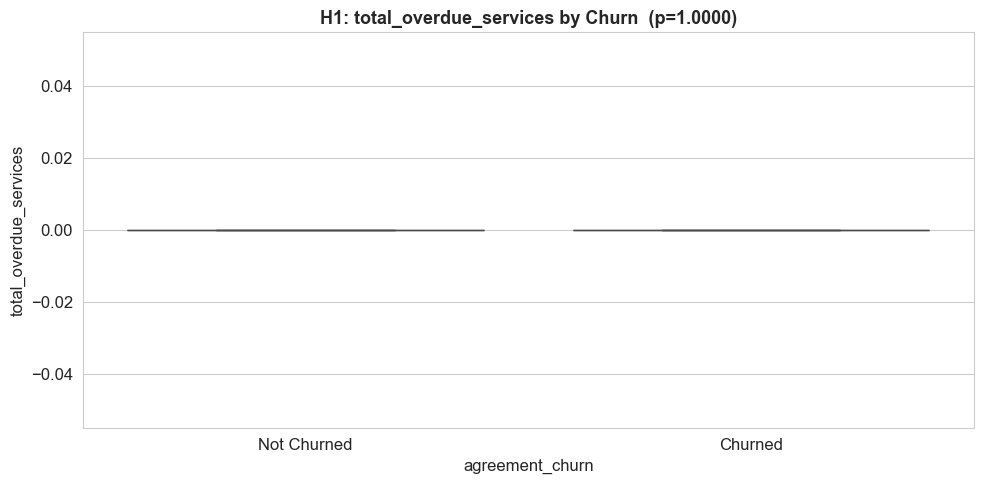

In [6]:
col = 'total_overdue_services'

if col in df.columns:
    # Run the test
    stat, p_val = stats.mannwhitneyu(
        churned[col].dropna(),
        not_churned[col].dropna(),
        alternative='greater'  # one-sided: churned > not_churned
    )
    conclusion = 'Reject H0 (significant)' if p_val < ALPHA else 'Fail to reject H0'
    results.append({'Hypothesis': 'H1: Overdue Services', 'Test': 'Mann-Whitney U',
                    'Statistic': round(stat, 2), 'p-value': round(p_val, 6),
                    'Conclusion': conclusion})

    print(f"Mann-Whitney U stat = {stat:.2f},  p-value = {p_val:.6f}")
    print(f"Conclusion: {conclusion}")

    # Visualise
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x=TARGET, y=col,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_xticklabels(['Not Churned', 'Churned'])
    ax.set_title(f'H1: {col} by Churn  (p={p_val:.4f})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{col}' not found — skipping H1.")

---
## H2 — Repair-to-Machine Ratio

**H₀:** No difference in repair ratio between groups.  
**H₁:** Churned customers have a higher repair-to-machine ratio.  
**Test:** Mann-Whitney U

Mann-Whitney U stat = 53966922.00,  p-value = 1.000000
Conclusion: Fail to reject H0


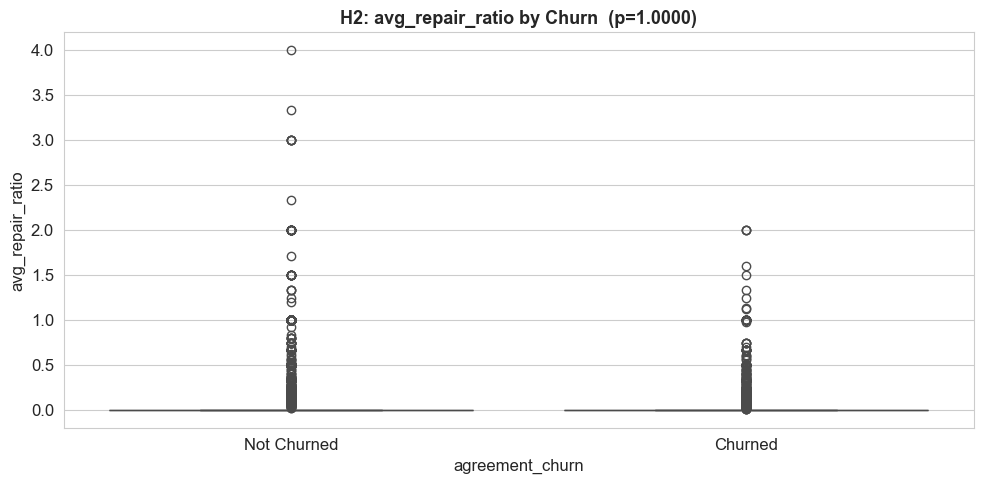

In [7]:
col = 'avg_repair_ratio'

if col in df.columns:
    stat, p_val = stats.mannwhitneyu(
        churned[col].dropna(),
        not_churned[col].dropna(),
        alternative='greater'
    )
    conclusion = 'Reject H0 (significant)' if p_val < ALPHA else 'Fail to reject H0'
    results.append({'Hypothesis': 'H2: Repair-to-Machine Ratio', 'Test': 'Mann-Whitney U',
                    'Statistic': round(stat, 2), 'p-value': round(p_val, 6),
                    'Conclusion': conclusion})

    print(f"Mann-Whitney U stat = {stat:.2f},  p-value = {p_val:.6f}")
    print(f"Conclusion: {conclusion}")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x=TARGET, y=col,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_xticklabels(['Not Churned', 'Churned'])
    ax.set_title(f'H2: {col} by Churn  (p={p_val:.4f})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{col}' not found — skipping H2.")

---
## H3 — Company Size vs Churn

**H₀:** Churn rate is independent of company size.  
**H₁:** Churn rate differs across company sizes.  
**Test:** Chi-Square test of independence

Chi-Square = 54.71,  p-value = 0.000000,  dof = 5
Conclusion: Reject H0 (significant)


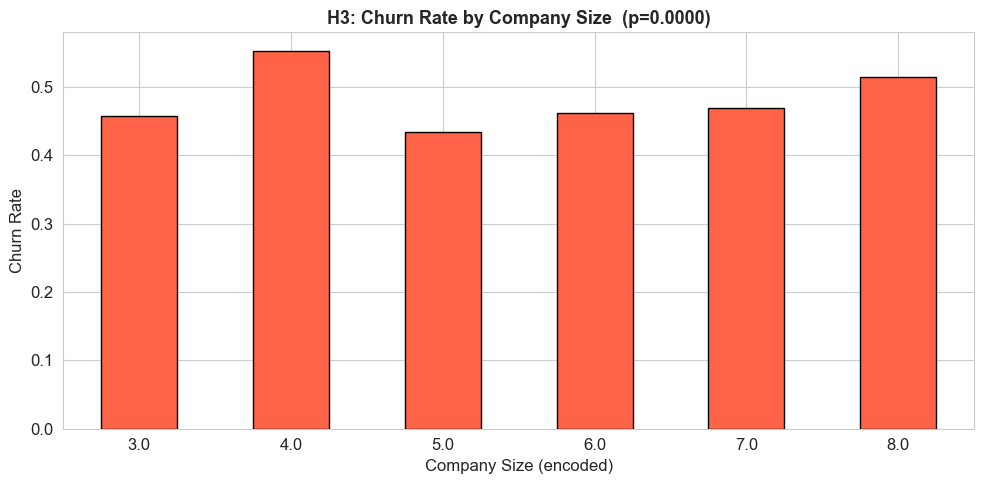

In [8]:
col = 'company_size_encoded'

if col in df.columns:
    # Build a contingency table
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, p_val, dof, expected = stats.chi2_contingency(ct)

    conclusion = 'Reject H0 (significant)' if p_val < ALPHA else 'Fail to reject H0'
    results.append({'Hypothesis': 'H3: Company Size', 'Test': 'Chi-Square',
                    'Statistic': round(chi2, 2), 'p-value': round(p_val, 6),
                    'Conclusion': conclusion})

    print(f"Chi-Square = {chi2:.2f},  p-value = {p_val:.6f},  dof = {dof}")
    print(f"Conclusion: {conclusion}")

    # Visualise churn rate per company size
    churn_rate = df.groupby(col)[TARGET].mean()
    fig, ax = plt.subplots(figsize=(10, 5))
    churn_rate.plot(kind='bar', color='tomato', edgecolor='black', ax=ax)
    ax.set_title(f'H3: Churn Rate by Company Size  (p={p_val:.4f})',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('Company Size (encoded)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{col}' not found — skipping H3.")

---
## H4 — Case Resolution Days

**H₀:** No difference in resolution time between groups.  
**H₁:** Churned customers have different resolution times.  
**Test:** Mann-Whitney U (two-sided)

In [9]:
col = 'avg_resolution_days'

if col in df.columns:
    stat, p_val = stats.mannwhitneyu(
        churned[col].dropna(),
        not_churned[col].dropna(),
        alternative='two-sided'
    )
    conclusion = 'Reject H0 (significant)' if p_val < ALPHA else 'Fail to reject H0'
    results.append({'Hypothesis': 'H4: Resolution Days', 'Test': 'Mann-Whitney U',
                    'Statistic': round(stat, 2), 'p-value': round(p_val, 6),
                    'Conclusion': conclusion})

    print(f"Mann-Whitney U stat = {stat:.2f},  p-value = {p_val:.6f}")
    print(f"Conclusion: {conclusion}")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x=TARGET, y=col,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_xticklabels(['Not Churned', 'Churned'])
    ax.set_title(f'H4: {col} by Churn  (p={p_val:.4f})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{col}' not found — skipping H4.")

Column 'avg_resolution_days' not found — skipping H4.


---
## H5 — Total Annual Value

**H₀:** No difference in total annual contract value.  
**H₁:** Churned customers have lower total annual value.  
**Test:** Mann-Whitney U (one-sided: churned < non-churned)

Mann-Whitney U stat = 2804755.00,  p-value = 0.001515
Conclusion: Reject H0 (significant)


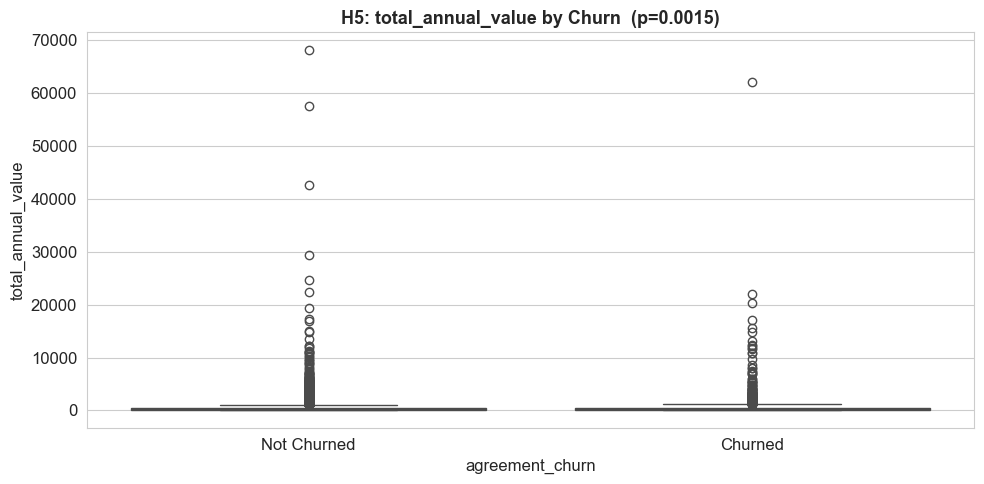

In [10]:
col = 'total_annual_value'

if col in df.columns:
    stat, p_val = stats.mannwhitneyu(
        churned[col].dropna(),
        not_churned[col].dropna(),
        alternative='less'  # churned < not_churned
    )
    conclusion = 'Reject H0 (significant)' if p_val < ALPHA else 'Fail to reject H0'
    results.append({'Hypothesis': 'H5: Total Annual Value', 'Test': 'Mann-Whitney U',
                    'Statistic': round(stat, 2), 'p-value': round(p_val, 6),
                    'Conclusion': conclusion})

    print(f"Mann-Whitney U stat = {stat:.2f},  p-value = {p_val:.6f}")
    print(f"Conclusion: {conclusion}")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x=TARGET, y=col,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_xticklabels(['Not Churned', 'Churned'])
    ax.set_title(f'H5: {col} by Churn  (p={p_val:.4f})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{col}' not found — skipping H5.")

---
## H6 — Number of Lines of Business

**H₀:** No difference in the diversity of product lines.  
**H₁:** Churned customers use fewer lines of business  
(less 'sticky' / less entangled with the company).  
**Test:** Mann-Whitney U

Mann-Whitney U stat = 3001558.50,  p-value = 0.818002
Conclusion: Fail to reject H0


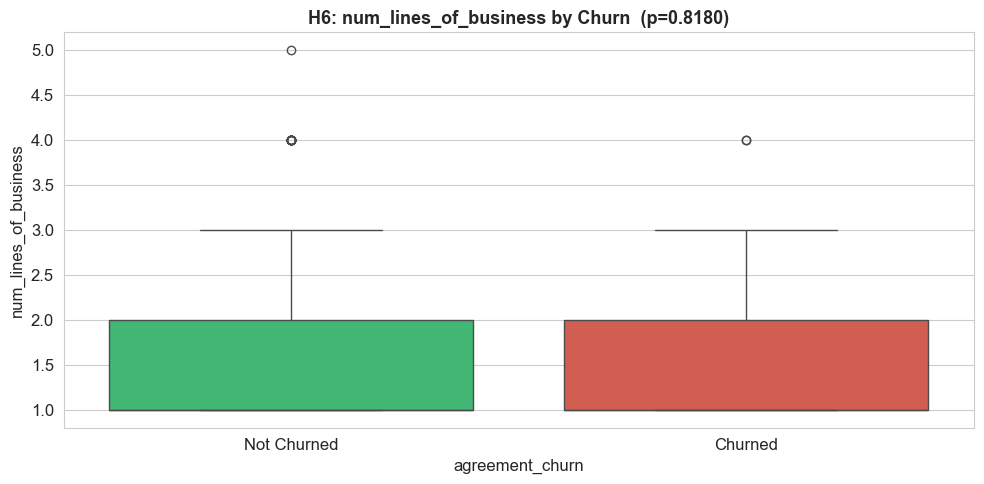

In [11]:
col = 'num_lines_of_business'

if col in df.columns:
    stat, p_val = stats.mannwhitneyu(
        churned[col].dropna(),
        not_churned[col].dropna(),
        alternative='less'  # churned < not_churned
    )
    conclusion = 'Reject H0 (significant)' if p_val < ALPHA else 'Fail to reject H0'
    results.append({'Hypothesis': 'H6: Lines of Business', 'Test': 'Mann-Whitney U',
                    'Statistic': round(stat, 2), 'p-value': round(p_val, 6),
                    'Conclusion': conclusion})

    print(f"Mann-Whitney U stat = {stat:.2f},  p-value = {p_val:.6f}")
    print(f"Conclusion: {conclusion}")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x=TARGET, y=col,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_xticklabels(['Not Churned', 'Churned'])
    ax.set_title(f'H6: {col} by Churn  (p={p_val:.4f})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{col}' not found — skipping H6.")

---
## H7 — Total Agreements

**H₀:** No difference in total agreement count.  
**H₁:** Churned customers have fewer total agreements.  
**Test:** Mann-Whitney U

Mann-Whitney U stat = 2993570.00,  p-value = 0.741582
Conclusion: Fail to reject H0


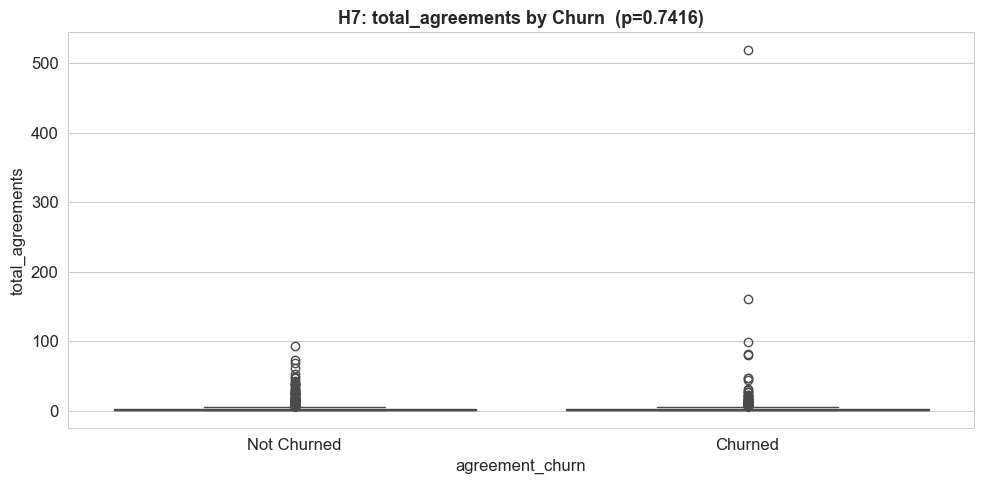

In [12]:
col = 'total_agreements'

if col in df.columns:
    stat, p_val = stats.mannwhitneyu(
        churned[col].dropna(),
        not_churned[col].dropna(),
        alternative='less'
    )
    conclusion = 'Reject H0 (significant)' if p_val < ALPHA else 'Fail to reject H0'
    results.append({'Hypothesis': 'H7: Total Agreements', 'Test': 'Mann-Whitney U',
                    'Statistic': round(stat, 2), 'p-value': round(p_val, 6),
                    'Conclusion': conclusion})

    print(f"Mann-Whitney U stat = {stat:.2f},  p-value = {p_val:.6f}")
    print(f"Conclusion: {conclusion}")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x=TARGET, y=col,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_xticklabels(['Not Churned', 'Churned'])
    ax.set_title(f'H7: {col} by Churn  (p={p_val:.4f})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{col}' not found — skipping H7.")

---
## H8 — VAN Changed

**H₀:** VAN changes are independent of churn.  
**H₁:** Customers whose VAN changed are more likely to churn.  
**Test:** Chi-Square

Chi-Square = 4641.15,  p-value = 0.000000,  dof = 1
Conclusion: Reject H0 (significant)


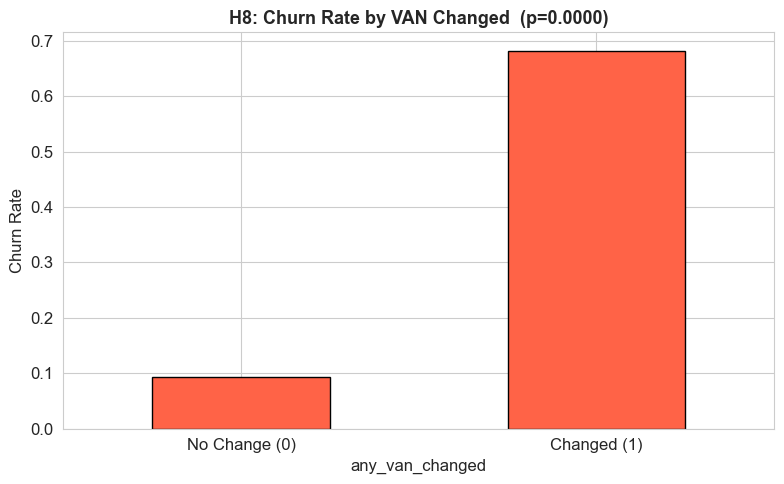

In [13]:
col = 'any_van_changed'

if col in df.columns:
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, p_val, dof, expected = stats.chi2_contingency(ct)

    conclusion = 'Reject H0 (significant)' if p_val < ALPHA else 'Fail to reject H0'
    results.append({'Hypothesis': 'H8: VAN Changed', 'Test': 'Chi-Square',
                    'Statistic': round(chi2, 2), 'p-value': round(p_val, 6),
                    'Conclusion': conclusion})

    print(f"Chi-Square = {chi2:.2f},  p-value = {p_val:.6f},  dof = {dof}")
    print(f"Conclusion: {conclusion}")

    # Visualise churn rate by VAN changed
    churn_rate = df.groupby(col)[TARGET].mean()
    fig, ax = plt.subplots(figsize=(8, 5))
    churn_rate.plot(kind='bar', color='tomato', edgecolor='black', ax=ax)
    ax.set_title(f'H8: Churn Rate by VAN Changed  (p={p_val:.4f})',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.set_xticklabels(['No Change (0)', 'Changed (1)'], rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{col}' not found — skipping H8.")

---
## Summary of All Hypothesis Tests

In [14]:
# ── Summary table ────────────────────────────────────────
# WHY: A single table makes it easy to compare all results
# at a glance and decide which features to keep.

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("HYPOTHESIS TESTING SUMMARY")
print("=" * 80)
results_df


HYPOTHESIS TESTING SUMMARY


,Hypothesis,Test,Statistic,p-value,Conclusion
0,H1: Overdue Services,Mann-Whitney U,56761320.00,1.000000,Fail to reject H0
1,H2: Repair-to-Machine Ratio,Mann-Whitney U,53966922.00,1.000000,Fail to reject H0
2,H3: Company Size,Chi-Square,54.71,0.000000,Reject H0 (significant)
3,H5: Total Annual Value,Mann-Whitney U,2804755.00,0.001515,Reject H0 (significant)
4,H6: Lines of Business,Mann-Whitney U,3001558.50,0.818002,Fail to reject H0
5,H7: Total Agreements,Mann-Whitney U,2993570.00,0.741582,Fail to reject H0
6,H8: VAN Changed,Chi-Square,4641.15,0.000000,Reject H0 (significant)


---
## Interpretation Guide

| Result | Meaning |
|---|---|
| **Reject H₀** (p < 0.05) | The feature has a statistically significant relationship with churn — **keep it** for modelling. |
| **Fail to reject H₀** (p ≥ 0.05) | No strong evidence of a relationship — **consider dropping** unless domain knowledge says otherwise. |

**Note:** Statistical significance ≠ practical significance.  
A feature can be significant but have tiny effect size.  
Always pair these results with the EDA visualisations.